In [ ]:
import os
import gc
import pandas as pd
import json
import joblib

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, fbeta_score
import numpy as np

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_lr.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_lr.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

In [3]:
base_lr = LogisticRegression(random_state=42)
base_lr.fit(X_train, y_train.squeeze())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:
param_grid = {
    "C": np.logspace(-4, 4, 20),
    "l1_ratio": [0.0, 0.5, 1.0],
    "solver": ["saga"],
    "class_weight": [None, "balanced"],
    "max_iter": [500, 1000, 2000]
}

lr = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=max(1, int(os.cpu_count() * 0.6)),
    verbose=2
)

lr.fit(X_train, y_train.squeeze())

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'class_weight': [None, 'balanced'], 'l1_ratio': [0.0, 0.5, ...], 'max_iter': [500, 1000, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",19
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [5]:
best_lr = lr.best_estimator_
print("Best Score:", lr.best_score_)
print("Best Hyperparameters:", lr.best_params_)

Best Score: 0.9030377681390339
Best Hyperparameters: {'solver': 'saga', 'max_iter': 2000, 'l1_ratio': 1.0, 'class_weight': None, 'C': np.float64(0.23357214690901212)}


In [6]:
y_preds_base = base_lr.predict(X_test)
y_preds = best_lr.predict(X_test)

print("\n--- Base LR ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds_base))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
print(classification_report(y_test.squeeze(), y_preds_base))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), base_lr.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds_base))

print("\n--- Tuned LR ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds, beta=2))
print(classification_report(y_test.squeeze(), y_preds))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), best_lr.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds))


--- Base LR ---
Accuracy: 0.8186813186813187
F2 Score: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        83
           1       0.80      0.89      0.84        99

    accuracy                           0.82       182
   macro avg       0.82      0.81      0.81       182
weighted avg       0.82      0.82      0.82       182

ROC-AUC: 0.9133503711816965
Confusion Matrix:
 [[61 22]
 [11 88]]

--- Tuned LR ---
Accuracy: 0.8241758241758241
F2 Score: 0.8712871287128713
              precision    recall  f1-score   support

           0       0.85      0.75      0.79        83
           1       0.81      0.89      0.85        99

    accuracy                           0.82       182
   macro avg       0.83      0.82      0.82       182
weighted avg       0.83      0.82      0.82       182

ROC-AUC: 0.9151758549348912
Confusion Matrix:
 [[62 21]
 [11 88]]


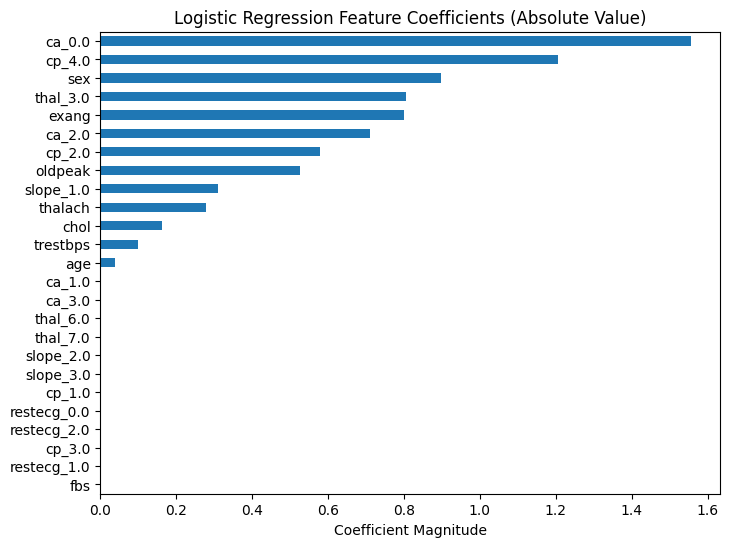

In [7]:
coefficients = pd.Series(np.abs(best_lr.coef_[0]), index=X_train.columns)
coefficients.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Logistic Regression Feature Coefficients (Absolute Value)')
plt.xlabel('Coefficient Magnitude')
plt.show()

In [ ]:
joblib.dump(best_lr, '../models/logistic_regression.pkl')

lr_results = {
    'base_lr': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds_base)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), base_lr.predict_proba(X_test)[:, 1])),
        'f2_score': float(fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
    },
    'tuned_lr': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), best_lr.predict_proba(X_test)[:, 1])),
        'f2_score': float(fbeta_score(y_test.squeeze(), y_preds, beta=2))
    }
}

with open(os.path.join(RESULTS_DIR, 'lr_results.json'), 'w') as f:
    json.dump(lr_results, f, indent=4)

: 

In [ ]:
gc.collect()